In [1]:
import uproot 
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

In [2]:
path_SM = "/home/tuhin/madgraph_projects/SM/Events/run_SM/tag_2_delphes_events.root"
path_SMEFT = "/home/tuhin/madgraph_projects/SMEFT/Events/run_SMEFT/tag_2_delphes_events.root"

In [3]:
root_SM, root_SMEFT = [uproot.open(path) for path in [path_SM,path_SMEFT]]
root_SM,root_SMEFT

(<ReadOnlyDirectory '/' at 0x7e8c23bbf3e0>,
 <ReadOnlyDirectory '/' at 0x7e8c2390aff0>)

In [4]:
tree_SM,tree_SMEFT = root_SM["Delphes;1"],root_SMEFT["Delphes;1"]

In [5]:
tree_SM.keys(filter_name = "Jet*")

['Jet',
 'Jet/Jet.fUniqueID',
 'Jet/Jet.fBits',
 'Jet/Jet.PT',
 'Jet/Jet.Eta',
 'Jet/Jet.Phi',
 'Jet/Jet.T',
 'Jet/Jet.Mass',
 'Jet/Jet.DeltaEta',
 'Jet/Jet.DeltaPhi',
 'Jet/Jet.Flavor',
 'Jet/Jet.FlavorAlgo',
 'Jet/Jet.FlavorPhys',
 'Jet/Jet.TauFlavor',
 'Jet/Jet.BTag',
 'Jet/Jet.BTagAlgo',
 'Jet/Jet.BTagPhys',
 'Jet/Jet.TauTag',
 'Jet/Jet.TauWeight',
 'Jet/Jet.Charge',
 'Jet/Jet.EhadOverEem',
 'Jet/Jet.NCharged',
 'Jet/Jet.NNeutrals',
 'Jet/Jet.NeutralEnergyFraction',
 'Jet/Jet.ChargedEnergyFraction',
 'Jet/Jet.Beta',
 'Jet/Jet.BetaStar',
 'Jet/Jet.MeanSqDeltaR',
 'Jet/Jet.PTD',
 'Jet/Jet.FracPt[5]',
 'Jet/Jet.Tau[5]',
 'Jet/Jet.SoftDroppedJet',
 'Jet/Jet.SoftDroppedSubJet1',
 'Jet/Jet.SoftDroppedSubJet2',
 'Jet/Jet.TrimmedP4[5]',
 'Jet/Jet.PrunedP4[5]',
 'Jet/Jet.SoftDroppedP4[5]',
 'Jet/Jet.NSubJetsTrimmed',
 'Jet/Jet.NSubJetsPruned',
 'Jet/Jet.NSubJetsSoftDropped',
 'Jet/Jet.ExclYmerge12',
 'Jet/Jet.ExclYmerge23',
 'Jet/Jet.ExclYmerge34',
 'Jet/Jet.ExclYmerge45',
 'Jet/Jet.ExclYme

In [6]:
required_branches = np.array(['PT','Eta','Phi','Flavor','Mass','BTag','NNeutrals','NCharged'])
data_dict = {
    "SM" : {
        "Jet" : tree_SM["Jet"].arrays("Jet." + required_branches,library = "ak"),
        "GenJet" : tree_SM["GenJet"].arrays("GenJet." + required_branches,library = "ak")
    },
    "SMEFT" : {
        "Jet" : tree_SMEFT["Jet"].arrays("Jet." + required_branches,library = "ak"),
        "GenJet" : tree_SMEFT["GenJet"].arrays("GenJet." + required_branches,library = "ak")
    }
}

In [7]:
plt.style.use("dark_background")

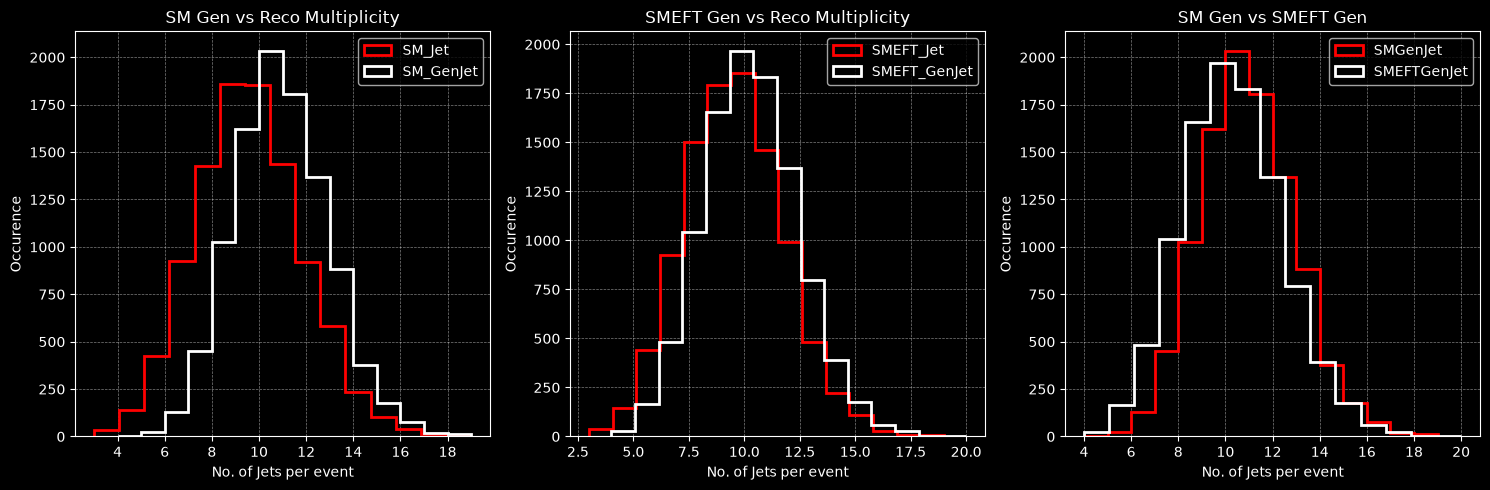

In [8]:
fig,ax = plt.subplots(1,3,figsize=(15,5))
for i,model in enumerate(["SM","SMEFT"]):
    for branch,color in zip(["Jet","GenJet"],["#FF0000","#FFFFFF"]):
        ax[i].hist(ak.num(data_dict[model][branch][f"{branch}.PT"],axis = 1),
                   bins = 15,
                   label = f"{model}_{branch}",
                   color = color,
                   histtype = "step",
                   lw = 2)
        ax[i].set_ylabel("Occurence")
        ax[i].set_xlabel("No. of Jets per event")
        ax[i].grid(True,ls = "--",lw = 0.5,which = "both",alpha = 0.5)
        ax[i].legend()
    ax[i].set_title(f"{model} Gen vs Reco Multiplicity")
    ax[2].hist(ak.num(data_dict[model]["GenJet"][f"GenJet.PT"],axis = 1),
               label = f"{model}GenJet",
               bins = 15,
               histtype = "step",
               color = "white" if i else "red",
               lw = 2)
    ax[2].legend()
    ax[2].set_ylabel("Occurence")
    ax[2].set_xlabel("No. of Jets per event")
    ax[2].grid(True,ls = "--",lw = 0.5,which = "both",alpha = 0.5)
ax[2].set_title(f"SM Gen vs SMEFT Gen")
plt.tight_layout()
plt.show()

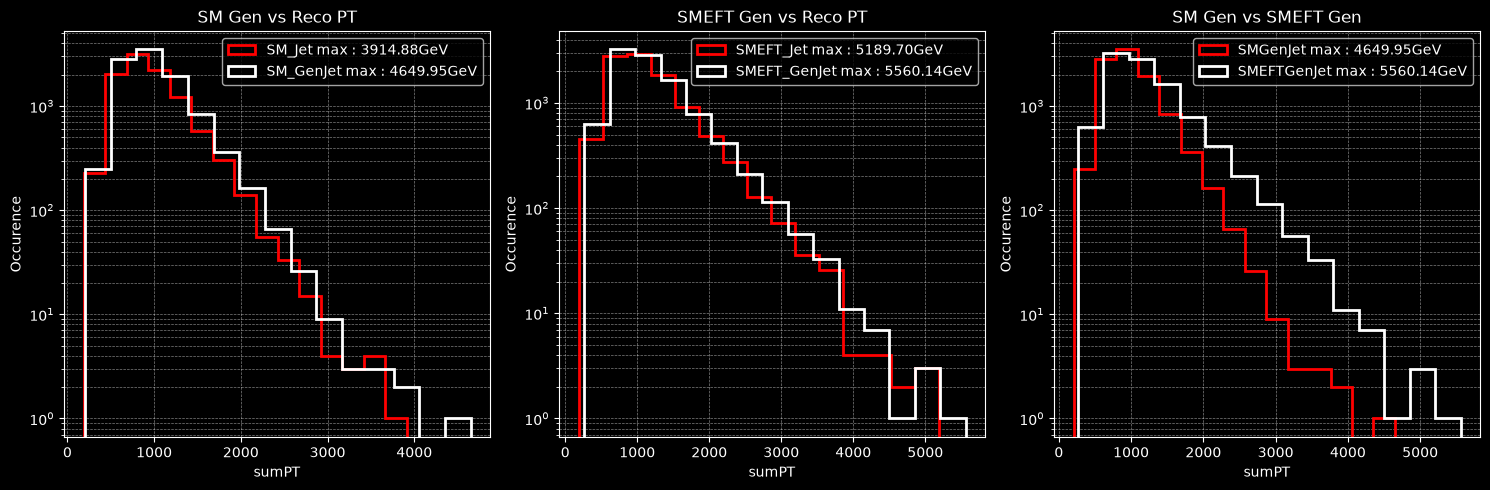

In [9]:
fig,ax = plt.subplots(1,3,figsize=(15,5))
for i,model in enumerate(["SM","SMEFT"]):
    for branch,color in zip(["Jet","GenJet"],["#FF0000","#FFFFFF"]):
        sumPT = ak.sum(data_dict[model][branch][f"{branch}.PT"],axis = 1)
        ax[i].hist(sumPT,
                   bins = 15,
                   label = f"{model}_{branch} max : {np.max(sumPT):.2f}GeV",
                #    alpha = 0.7,
                   color = color,
                   histtype = "step",
                   lw = 2)
        ax[i].set_ylabel("Occurence")
        ax[i].set_xlabel(" sumPT ")
        ax[i].set_yscale("log")
        ax[i].legend()
    ax[i].set_title(f"{model} Gen vs Reco PT")
    ax[i].grid(True,ls = "--",lw = 0.5,which = "both",alpha = 0.5)
    genjet_sumPT = ak.sum(data_dict[model]["GenJet"][f"GenJet.PT"],axis = 1)
    ax[2].hist(genjet_sumPT,
               label = f"{model}GenJet max : {np.max(genjet_sumPT):.2f}GeV",
               bins = 15,
               histtype = "step",
               color = "white" if i else "red",
               lw = 2)
    ax[2].legend()
    ax[2].set_ylabel("Occurence")
    ax[2].set_xlabel("sumPT")
    ax[2].set_yscale("log")
ax[2].set_title(f"SM Gen vs SMEFT Gen")
ax[2].grid(True,ls = "--",lw = 0.5,which = "both",alpha = 0.5)
plt.tight_layout()
plt.show()

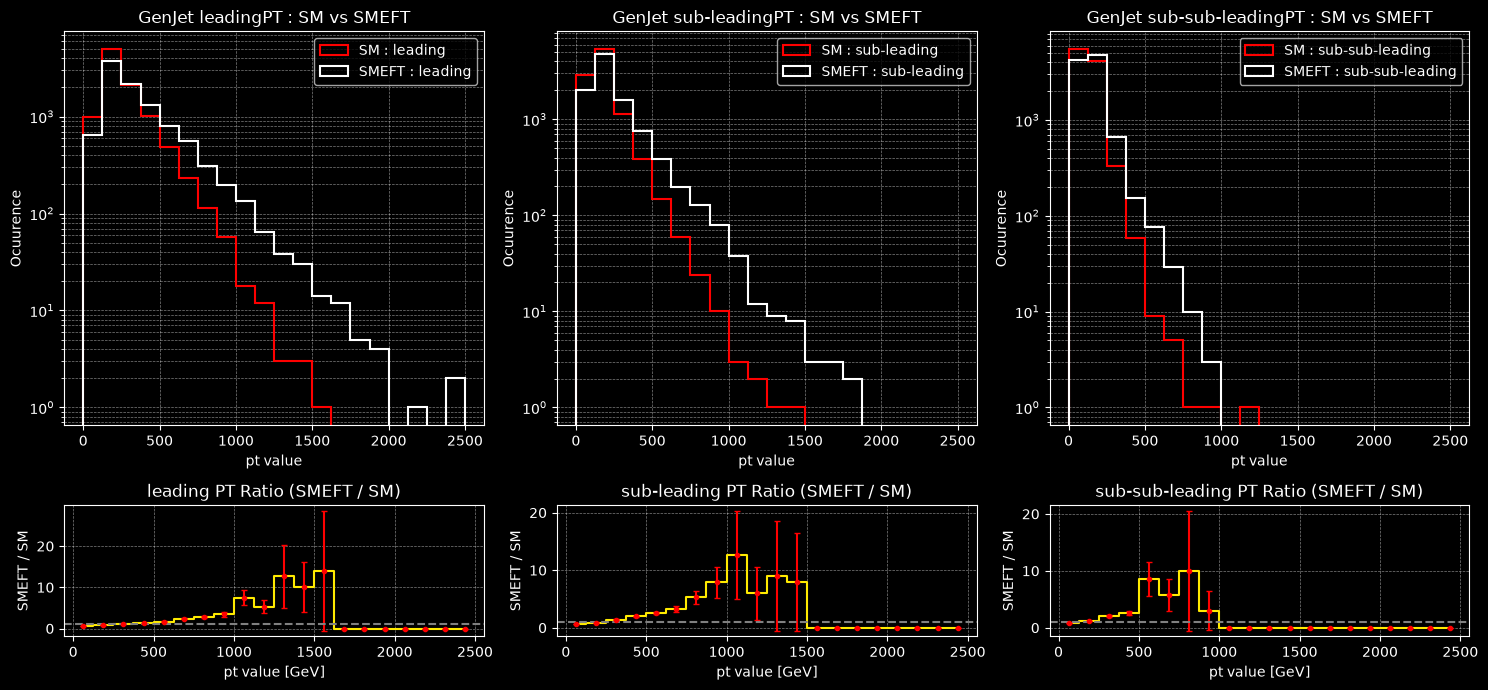

In [10]:
fig,ax = plt.subplots(2,3,figsize=(15,7),gridspec_kw={"height_ratios": [3, 1]})
arrSM = []
arrSMEFT = []
bins = np.linspace(0,2500,21)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
for model,color in zip(["SM","SMEFT"],["#FF0000","#FFFFFF"]):
    genJetPT = data_dict[model]["GenJet"]["GenJet.PT"]
    genJetPT = genJetPT[(ak.num(genJetPT,axis = 1))>=3]
    for j in range(3):
        occurence,b,c = ax[0,j].hist(genJetPT[:,j],bins = bins,histtype = "step",
                   label = f"{model} : {j*"sub-"}leading",
                   color = color,
                   lw = 1.5)
        ax[0,j].legend()
        ax[0,j].set_title(f"GenJet {j*"sub-"}leadingPT : SM vs SMEFT")
        ax[0,j].grid(True,ls = "--",lw = 0.5,which = "both",alpha = 0.5)
        ax[0,j].set_xlabel("pt value")
        ax[0,j].set_ylabel("Ocuurence")
        ax[0,j].set_yscale("log")
        arr = arrSM if model == "SM" else arrSMEFT
        arr.append(occurence)

arrSM = np.array(arrSM)
arrSMEFT = np.array(arrSMEFT)

with np.errstate(divide="ignore", invalid="ignore"):
    tot_arr = np.where(arrSM != 0, arrSMEFT / arrSM, 0.0)
    err = tot_arr * np.sqrt(np.where(arrSMEFT > 0, 1.0 / arrSMEFT, 0) + np.where(arrSM > 0, 1.0 / arrSM, 0))

for k in range(3):
    ax[1,k].step(bin_centers, tot_arr[k], where="mid", color="#FFEA00", lw=1.5)
    ax[1,k].errorbar(bin_centers, tot_arr[k], yerr=err[k], fmt="o", color="#FF0000", markersize=3, capsize=2, lw=1.5)
    ax[1,k].axhline(1.0, color="gray", linestyle="--")
    ax[1,k].set_title(f"{k*'sub-'}leading PT Ratio (SMEFT / SM)")
    ax[1,k].set_xlabel("pt value [GeV]")
    ax[1,k].set_ylabel("SMEFT / SM")
    ax[1,k].grid(True,ls = "--",lw = 0.5,which = "both",alpha = 0.5)

plt.tight_layout()
plt.show()


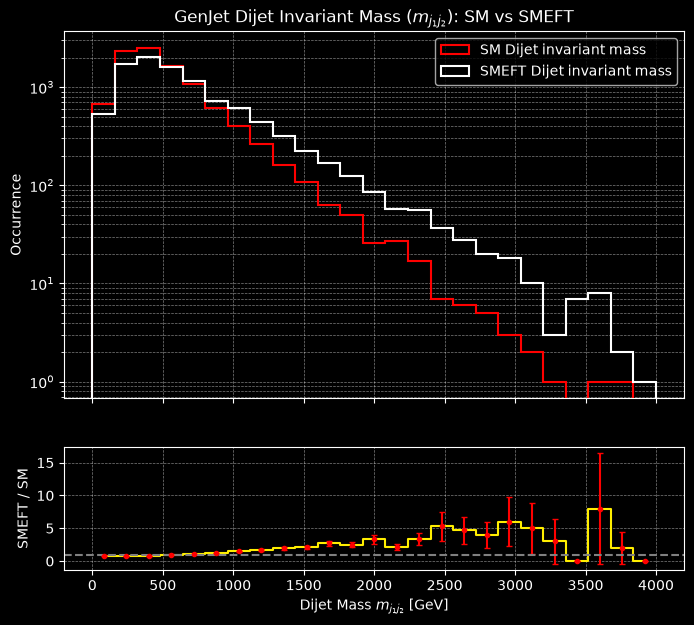

In [11]:
import vector
vector.register_awkward()

fig,ax = plt.subplots(2,1,figsize = (8,7),sharex=True,gridspec_kw={"height_ratios": [3,1]})

bins = np.linspace(0, 4000, 26)
bin_centers = 0.5 * (bins[:-1] + bins[1:])

arr_occurence = {}

for model,color in zip(["SM","SMEFT"],["#FF0000","#FFFFFF"]):
    genjet = data_dict[model]["GenJet"]
    mask = ak.num(genjet["GenJet.PT"],axis = 1) >= 2

    j_list = []

    for k in range(2):
        j_list.append(
            vector.zip({
                "pt": genjet["GenJet.PT"][mask][:, k],
                "eta": genjet["GenJet.Eta"][mask][:, k],
                "phi": genjet["GenJet.Phi"][mask][:, k],
                "mass": genjet["GenJet.Mass"][mask][:, k],
            })
        )

    j1, j2 = j_list
    m12 = (j1 + j2).mass
    occurence,_,_ = ax[0].hist(m12,histtype = "step",bins = bins,
                               color = color,lw = 1.5,
                               label = f"{model} Dijet invariant mass")

    ax[0].set_yscale("log")
    ax[0].set_ylabel("Occurrence")
    ax[0].set_title("GenJet Dijet Invariant Mass ($m_{j_1 j_2}$): SM vs SMEFT")
    ax[0].legend()
    ax[0].grid(True,ls = "--",lw = 0.5,which = "both",alpha = 0.5)

    arr_occurence[model] = np.array(occurence)

with np.errstate(divide="ignore", invalid="ignore"):
    ratio = np.where(
        arr_occurence["SM"] != 0, arr_occurence["SMEFT"] / arr_occurence["SM"], 0.0
    )
    err = ratio * np.sqrt(np.where(arr_occurence["SMEFT"] > 0, 1.0 / arr_occurence["SMEFT"], 0) + np.where(arr_occurence["SM"] > 0, 1.0 / arr_occurence["SM"], 0))

ax[1].step(bin_centers, ratio, where="mid", color="#FFEE00", lw=1.5)
ax[1].errorbar(bin_centers, ratio, yerr=err, fmt="o", color="#FF0000", markersize=3, capsize=2, lw=1.5)
ax[1].axhline(1.0, color="gray", linestyle="--")
ax[1].set_xlabel("Dijet Mass $m_{j_1 j_2}$ [GeV]")
ax[1].set_ylabel("SMEFT / SM")
ax[1].grid(True,ls = "--",lw = 0.5,which = "both",alpha = 0.5)
# ax[1].set_xlim(0, 3500)

plt.show()

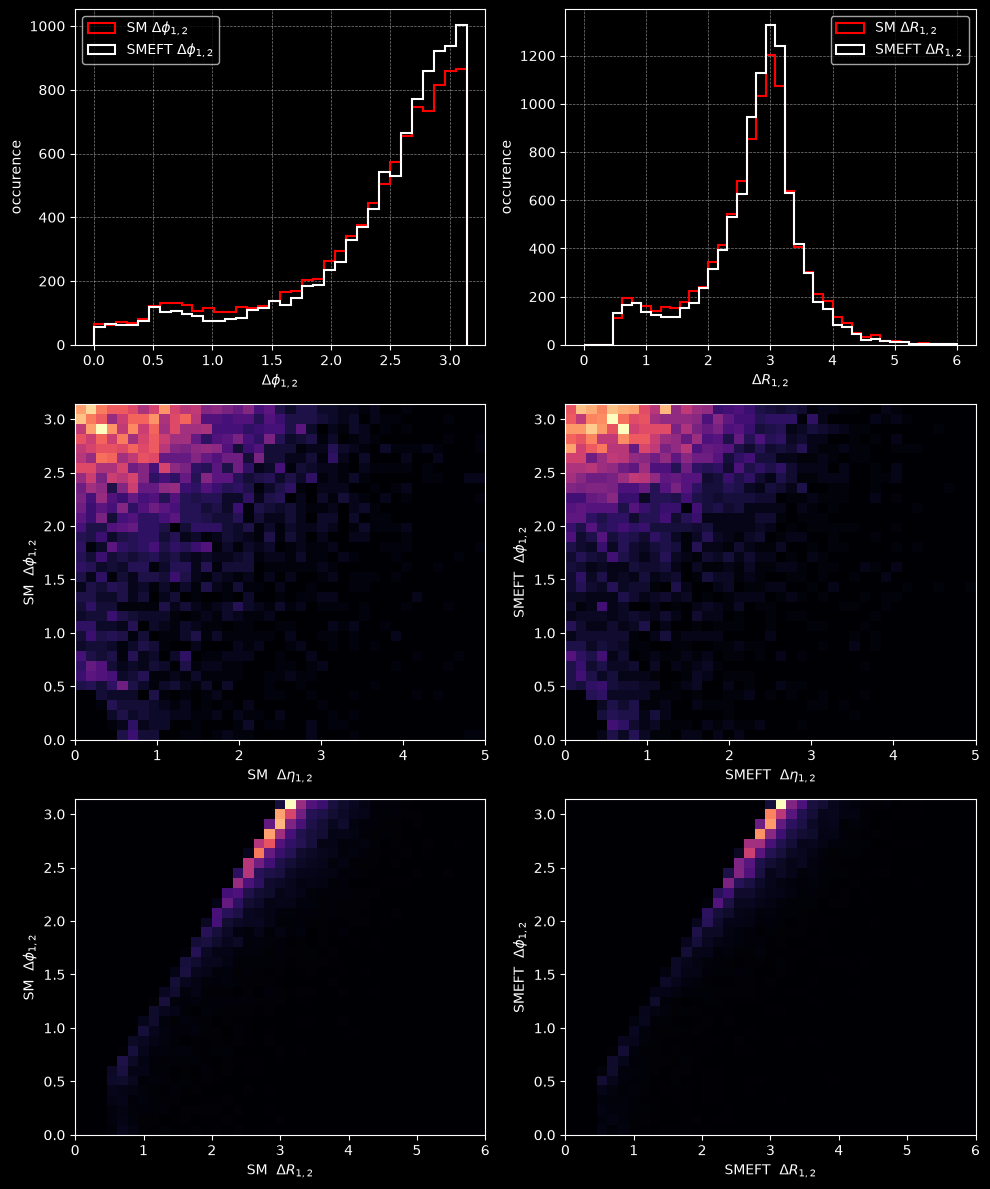

In [12]:
bins_dphi = np.linspace(0,np.pi,35)
bins_delR = np.linspace(0,6.0,40)
bins_deta = np.linspace(0,5.0,40)

fig,ax = plt.subplots(3,2,figsize = (10,12))

for j,(model,color) in enumerate(zip(["SM","SMEFT"],["#FF0000","#FFFFFF"])):
    
    phi = data_dict[model]["GenJet"]["GenJet.Phi"]
    mask = ak.num(phi,axis = 1)>=4
    phi = phi[mask]

    eta = data_dict[model]["GenJet"]["GenJet.Eta"]
    eta = eta[mask]

    dphi = np.array(abs(phi[:,0]-phi[:,1]))
    dphi = np.where(dphi>np.pi,2*np.pi-dphi,dphi)

    deta = np.array(eta[:,0]-eta[:,1])

    delR = np.sqrt(deta**2+dphi**2)

    ax[0,0].hist(dphi,histtype = "step",bins = bins_dphi,color = color,
             label = fr"{model} $\Delta \phi_{{1,2}}$",
             lw = 1.5)
    ax[0,1].hist(delR,histtype = "step",bins = bins_delR,color = color,
                 label = fr"{model} $\Delta R_{{1,2}}$",
                 lw = 1.5)

    ax[0,0].legend()
    ax[0,0].set_xlabel(r"$\Delta \phi_{{1,2}}$")
    ax[0,0].set_ylabel("occurence")
    ax[0,0].grid(True,ls = "--",lw = 0.5,which = "both",alpha = 0.5)
    ax[0,1].legend()
    ax[0,1].set_xlabel(r"$\Delta R_{{1,2}}$")
    ax[0,1].set_ylabel("occurence")
    ax[0,1].grid(True,ls = "--",lw = 0.5,which = "both",alpha = 0.5)

    ax[1,j].hist2d(deta,dphi,bins = [bins_deta,bins_dphi],cmap = "magma",density = True)
    ax[2,j].hist2d(delR,dphi,bins = [bins_delR,bins_dphi],cmap = "magma",density = True)

    ax[1,j].set_xlabel(fr"{model}  $\Delta \eta_{{1,2}}$")
    ax[2,j].set_xlabel(fr"{model}  $\Delta R_{{1,2}}$")
    
    ax[1,j].set_ylabel(fr"{model}  $\Delta \phi_{{1,2}}$")
    ax[2,j].set_ylabel(fr"{model}  $\Delta \phi_{{1,2}}$")


plt.tight_layout()
plt.show()

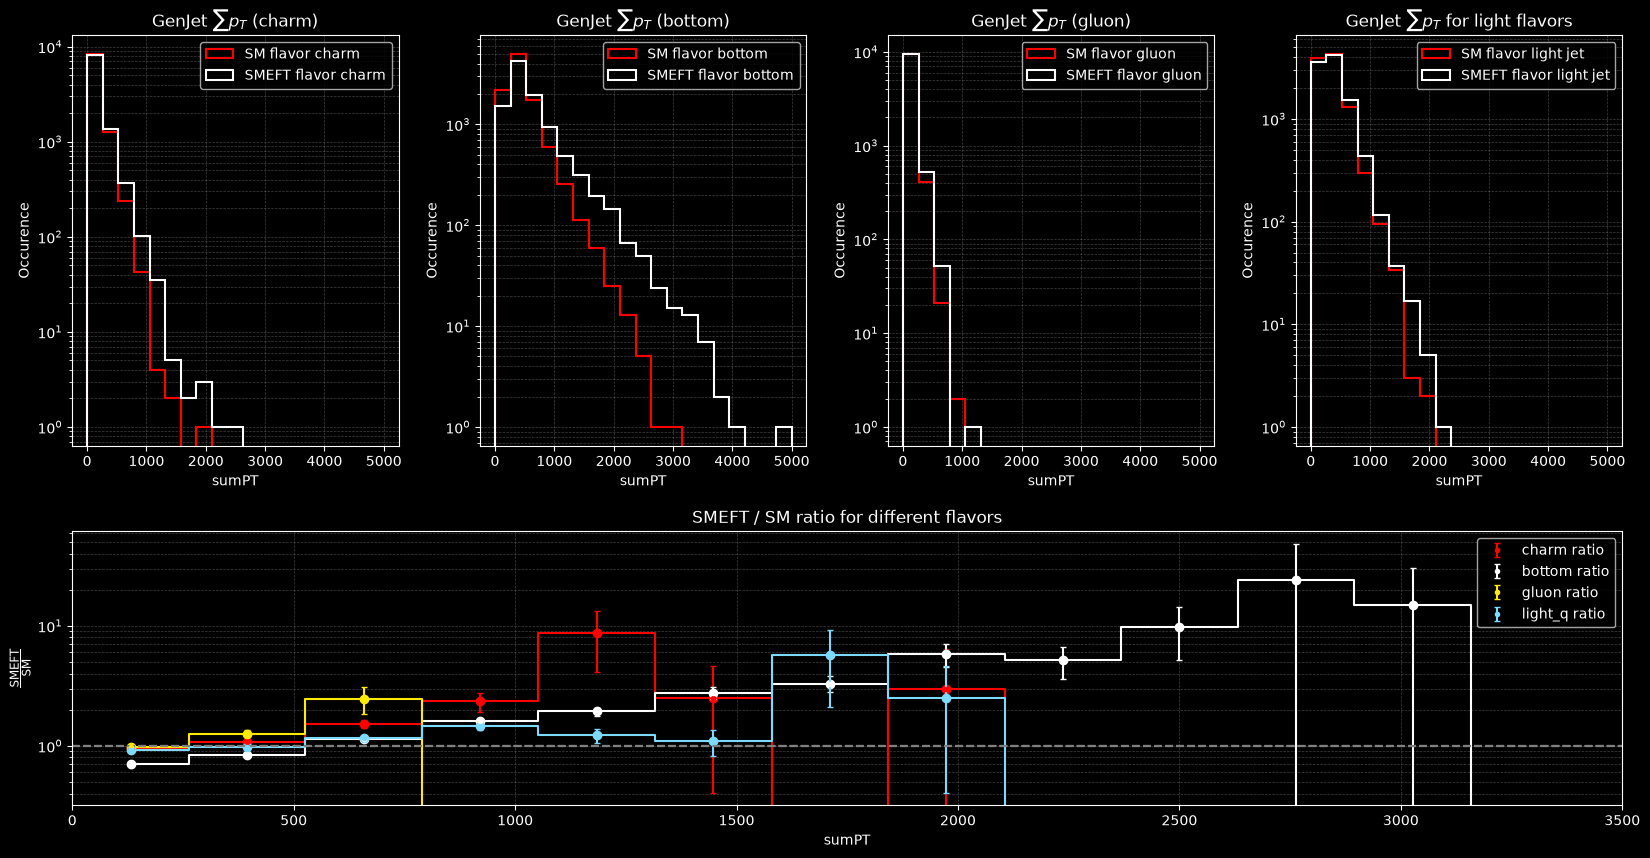

In [13]:
fig=plt.figure(figsize=(20,10))

bins = np.linspace(0,5000,20)
bins_centre = 0.5 * (bins[:-1] + bins[1:])

gs = fig.add_gridspec(2,4,height_ratios=[1.5,1],hspace = 0.25,wspace = 0.25)
ax_top = [fig.add_subplot(gs[0, i]) for i in range(4)]
ax_bottom = fig.add_subplot(gs[1, :])


arr_occurence = {}

for model,color in zip(["SM","SMEFT"],["#FF0000","#FFFFFF"]):
    genjet = data_dict[model]["GenJet"]
    mask = ak.num(genjet["GenJet.PT"],axis = 1)>=2
    genjet = data_dict[model]["GenJet"][mask]

    for i,(flavor,flavor_name) in enumerate({4: "charm", 5: "bottom", 21: "gluon"}.items()):
        genjet_pt = genjet["GenJet.PT"]
        flavor_mask = genjet["GenJet.Flavor"] == flavor
        genjet_pt = genjet_pt[flavor_mask]
        sumpt = ak.to_numpy(ak.sum(genjet_pt,axis = 1))

        occurence,_,_ = ax_top[i].hist(sumpt,bins = bins,histtype = "step",
                   lw = 1.5,label = f"{model} flavor {flavor_name}",
                   color = color)
        
        arr_occurence[model,flavor_name] = occurence
        ax_top[i].set_xlabel("sumPT")
        ax_top[i].set_ylabel("Occurence")
        ax_top[i].set_title(fr"GenJet $\sum p_T$ ({flavor_name})")
        ax_top[i].set_yscale("log")
        ax_top[i].grid(True,ls = "--",lw = 0.5,which = "both",color = "gray",alpha = 0.5)
        ax_top[i].legend()
        if flavor == 4:
            genjet_pt = genjet["GenJet.PT"]
            flavor_mask = genjet["GenJet.Flavor"] < flavor
            genjet_pt = genjet_pt[flavor_mask]
            sumpt = ak.to_numpy(ak.sum(genjet_pt,axis = 1))
            occurence,_,_ = ax_top[3].hist(sumpt,bins = bins,histtype = "step",
                       lw = 1.5,label = f"{model} flavor light jet",
                       color = color)
            arr_occurence[model, "light_q"] = occurence
            ax_top[3].set_xlabel("sumPT")
            ax_top[3].set_ylabel("Occurence")
            ax_top[3].set_title(fr"GenJet $\sum p_T$ for light flavors")
            ax_top[3].set_yscale("log")
            ax_top[3].grid(True,ls = "--",lw = 0.5,which = "both",color = "gray",alpha = 0.5)
            ax_top[3].legend()

for color,f_name in zip(["#FF0000","#FFFFFF","#FFEA00","#7CDAFF"], ["charm", "bottom", "gluon", "light_q"]):
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(
            arr_occurence["SM",f_name] != 0, arr_occurence["SMEFT",f_name] / arr_occurence["SM",f_name], 0.0
        )
        err = ratio * np.sqrt(np.where(arr_occurence["SMEFT",f_name] > 0, 1.0 / arr_occurence["SMEFT",f_name], 0) + np.where(arr_occurence["SM",f_name] > 0, 1.0 / arr_occurence["SM",f_name], 0))
    ax_bottom.step(bins_centre,ratio,marker = "o",where = "mid",color = color,lw = 1.5)
    ax_bottom.errorbar(bins_centre, ratio, yerr=err, fmt="o", color=color, markersize=3, capsize=2, lw=1.5,label=f"{f_name} ratio")
    ax_bottom.axhline(1.0, color="gray", linestyle="--")
    ax_bottom.set_xlabel("sumPT")
    ax_bottom.set_ylabel(r"$\frac{\text{SMEFT}}{\text{SM}}$",fontsize = 12)
    ax_bottom.set_yscale("log")
    ax_bottom.set_title("SMEFT / SM ratio for different flavors")
    ax_bottom.set_xlim(0, 3500)
    ax_bottom.grid(True,ls = "--",lw = 0.5,which = "both",color = "gray",alpha = 0.5)

ax_bottom.legend()
plt.show()    

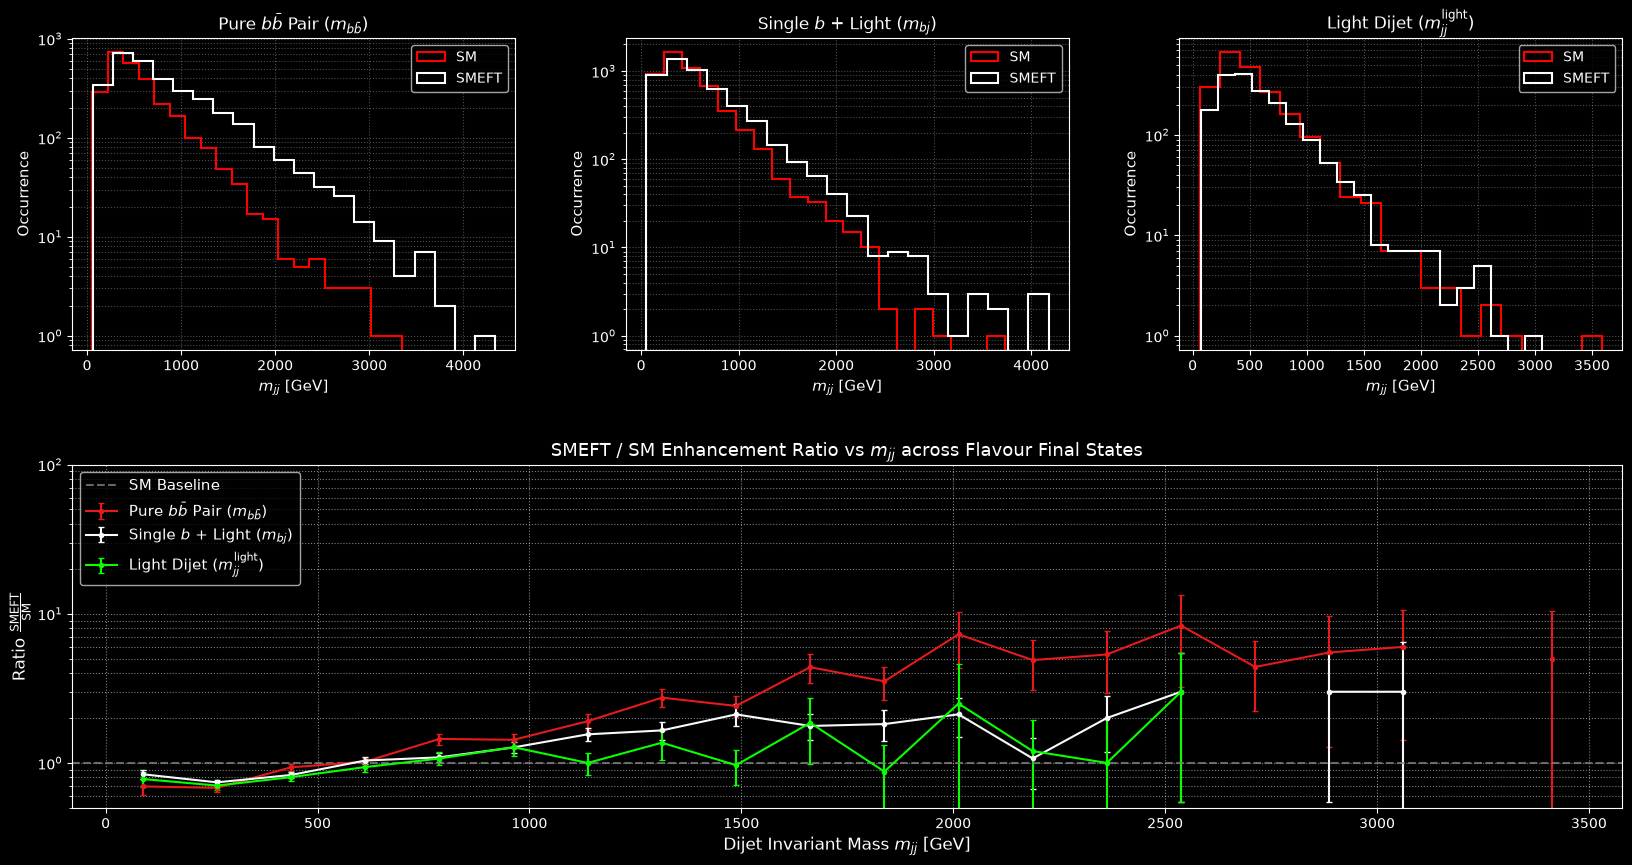

In [14]:
fig = plt.figure(figsize=(20, 10))
gs = fig.add_gridspec(2, 3, height_ratios=[1, 1.1], hspace=0.35, wspace=0.25)

ax_top = [
    fig.add_subplot(gs[0, 0]),
    fig.add_subplot(gs[0, 1]),
    fig.add_subplot(gs[0, 2]),
]
ax_bottom = fig.add_subplot(gs[1, :])

bins = 20
m_range = (0, 3500)

categories = ["bb", "bj", "light"]
cat_titles = {
    "bb": r"Pure $b\bar{b}$ Pair ($m_{b\bar{b}}$)",
    "bj": r"Single $b$ + Light ($m_{bj}$)",
    "light": r"Light Dijet ($m_{jj}^{\text{light}}$)",
}
colors = ["#e41a1c", "#f7f9fc", "#09ff00"]

for model in ["SM", "SMEFT"]:
    gen = data_dict[model]["GenJet"]
    mask_2jets = ak.num(gen["GenJet.PT"], axis=1) >= 2
    gen = gen[mask_2jets]

    pt = gen["GenJet.PT"][:, :2]
    eta = gen["GenJet.Eta"][:, :2]
    phi = gen["GenJet.Phi"][:, :2]
    mass = gen["GenJet.Mass"][:, :2]
    flv = np.abs(gen["GenJet.Flavor"][:, :2])

    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    E = np.sqrt(px**2 + py**2 + pz**2 + mass**2)

    E_tot = ak.sum(E, axis=1)
    px_tot = ak.sum(px, axis=1)
    py_tot = ak.sum(py, axis=1)
    pz_tot = ak.sum(pz, axis=1)

    mjj = ak.to_numpy(np.sqrt(np.maximum(0, E_tot**2 - (px_tot**2 + py_tot**2 + pz_tot**2))))

    num_bjet = ak.to_numpy(ak.sum(flv == 5, axis=1))

    if model == "SM":
        mjj_sm = {
            "bb": mjj[num_bjet >= 2],
            "bj": mjj[num_bjet == 1],
            "light": mjj[num_bjet == 0],
        }
    else:
        mjj_smeft = {
            "bb": mjj[num_bjet >= 2],
            "bj": mjj[num_bjet == 1],
            "light": mjj[num_bjet == 0],
        }

for i, cat in enumerate(categories):
    ax_top[i].hist(mjj_sm[cat],bins=bins,histtype="step",color="#FF0000",lw=1.5,label="SM")
    ax_top[i].hist(mjj_smeft[cat],bins=bins,histtype="step",color="#FFFFFF",lw=1.5,label="SMEFT")

    ax_top[i].set_xlabel(r"$m_{jj}$ [GeV]", fontsize=11)
    ax_top[i].set_ylabel("Occurrence", fontsize=11)
    ax_top[i].set_title(cat_titles[cat], fontsize=12)
    ax_top[i].set_yscale("log")
    ax_top[i].legend(fontsize=10)
    ax_top[i].grid(True, which="both", linestyle=":", alpha=0.3)

for cat, color in zip(categories, colors):
    counts_sm, bin_edges = np.histogram(mjj_sm[cat], bins=bins, range=m_range)
    counts_smeft, _ = np.histogram(mjj_smeft[cat], bins=bins, range=m_range)

    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(counts_sm > 0, counts_smeft / counts_sm, np.nan)
        err = ratio * np.sqrt(np.where(counts_smeft > 0, 1.0 / counts_smeft, 0) + np.where(counts_sm > 0, 1.0 / counts_sm, 0))

    # ax_bottom.step(bin_centers,ratio,label=cat_titles[cat],color=color,ms=5,lw=2,)
    ax_bottom.errorbar(bin_centers, ratio, yerr=err, fmt="o-", color=color, markersize=3, capsize=2, lw=1.5,label=cat_titles[cat])

ax_bottom.axhline(1.0, color="gray", linestyle="--", alpha=0.8, label="SM Baseline")

ax_bottom.set_xlabel(r"Dijet Invariant Mass $m_{jj}$ [GeV]", fontsize=12)
ax_bottom.set_ylabel(r"Ratio $\frac{\text{SMEFT}}{\text{SM}}$", fontsize=12)
ax_bottom.set_title(r"SMEFT / SM Enhancement Ratio vs $m_{jj}$ across Flavour Final States",fontsize=13,)
ax_bottom.set_yscale("log")
ax_bottom.set_ylim(0.5, 100)
ax_bottom.grid(True, which="both", linestyle=":", alpha=0.5)
ax_bottom.legend(fontsize=11, loc="upper left")

plt.show()

In [15]:
required_branches

array(['PT', 'Eta', 'Phi', 'Flavor', 'Mass', 'BTag', 'NNeutrals',
       'NCharged'], dtype='<U9')

SM Reconstructed W Mass: 81.41 GeV
SM Reconstructed Top Mass: 170.69 GeV
SMEFT Reconstructed W Mass: 82.26 GeV
SMEFT Reconstructed Top Mass: 172.59 GeV


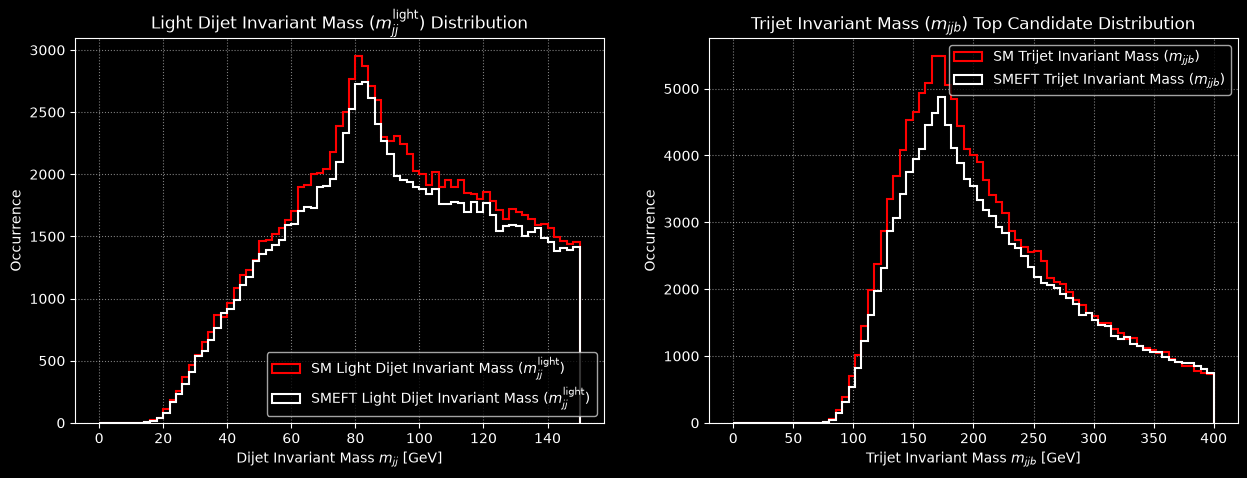

In [16]:
vector.register_awkward()

fig,ax = plt.subplots(1,2,figsize = (15,5))

for model,color in zip(["SM","SMEFT"],["#FF0000","#FFFFFF"]):
    genjet = data_dict[model]["GenJet"]

    non_b_mask = abs(genjet["GenJet.Flavor"]) != 5
    b_mask = abs(genjet["GenJet.Flavor"]) == 5

    genjet_light = genjet[non_b_mask]
    genjet_b = genjet[b_mask]

    jet_pairs = ak.combinations(genjet_light, 2, axis=1)

    j1 = vector.zip({
        "pt":   jet_pairs["0","0"],
        "eta":  jet_pairs["1","0"],
        "phi":  jet_pairs["2","0"],
        "mass": jet_pairs["4","0"]
    })

    j2 = vector.zip({
        "pt":   jet_pairs["0","1"],
        "eta":  jet_pairs["1","1"],
        "phi":  jet_pairs["2","1"],
        "mass": jet_pairs["4","1"]
    })

    dijet = j1+j2

    b_jets = vector.zip({
        "pt": genjet_b["GenJet.PT"],
        "eta": genjet_b["GenJet.Eta"],
        "phi": genjet_b["GenJet.Phi"],
        "mass": genjet_b["GenJet.Mass"],
    })

    m_jj = dijet.mass

    occurrence_w,val_w,_ = ax[0].hist(ak.flatten(m_jj), bins=75, histtype="step",
             range = (0,150), color=color, lw=1.5,
             label = fr"{model} Light Dijet Invariant Mass ($m_{{jj}}^{{\text{{light}}}}$)")
    ax[0].set_xlabel(r"Dijet Invariant Mass $m_{jj}$ [GeV]")
    ax[0].set_ylabel("Occurrence")
    ax[0].set_title(r"Light Dijet Invariant Mass ($m_{jj}^{\text{light}}$) Distribution")
    ax[0].grid(True, which="both", linestyle=":", alpha=0.5)
    ax[0].legend()

    peak_idx_w = np.argmax(occurrence_w)
    bin_centers_w = 0.5 * (val_w[:-1] + val_w[1:])
    
    a_w, b_w, c_w = np.polyfit(bin_centers_w[peak_idx_w - 1 : peak_idx_w + 2], occurrence_w[peak_idx_w - 1 : peak_idx_w + 2], 2)
    m_W_reconstructed = -b_w / (2 * a_w)


    w_window = 20.0 
    w_mask = (dijet.mass >= (m_W_reconstructed - w_window)) & (dijet.mass <= (m_W_reconstructed + w_window))
    dijet_filtered = dijet[w_mask]
    w_cand, b_cand = ak.unzip(ak.cartesian([dijet_filtered, b_jets], axis=1))
    top_cand = w_cand + b_cand

    m_jjb = top_cand.mass

    occurrence_t,val_t,_ = ax[1].hist(ak.flatten(m_jjb), bins=75, histtype="step",
                 range = (0,400), color=color, lw=1.5,
                 label = fr"{model} Trijet Invariant Mass ($m_{{jjb}}$)")
    
    ax[1].set_xlabel(r"Trijet Invariant Mass $m_{jjb}$ [GeV]")
    ax[1].set_ylabel("Occurrence")
    ax[1].set_title(r"Trijet Invariant Mass ($m_{jjb}$) Top Candidate Distribution")
    ax[1].grid(True, which="both", linestyle=":", alpha=0.5)
    ax[1].legend()

    peak_idx_t = np.argmax(occurrence_t)
    bin_centers_t = 0.5 * (val_t[:-1] + val_t[1:])

    a_t, b_t, c_t = np.polyfit(bin_centers_t[peak_idx_t - 1 : peak_idx_t + 2], occurrence_t[peak_idx_t - 1 : peak_idx_t + 2], 2)
    m_T_reconstructed = -b_t / (2 * a_t)

    print(f"{model} Reconstructed W Mass: {m_W_reconstructed:.2f} GeV")
    print(f"{model} Reconstructed Top Mass: {m_T_reconstructed:.2f} GeV")

plt.show()

/home/tuhin/miniconda3/envs/physics/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:300: RuntimeWarning: invalid value encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))
/home/tuhin/miniconda3/envs/physics/lib/python3.12/site-packages/awkward/_nplikes/array_module.py:300: RuntimeWarning: divide by zero encountered in divide
  return impl(*broadcasted_args, **(kwargs or {}))


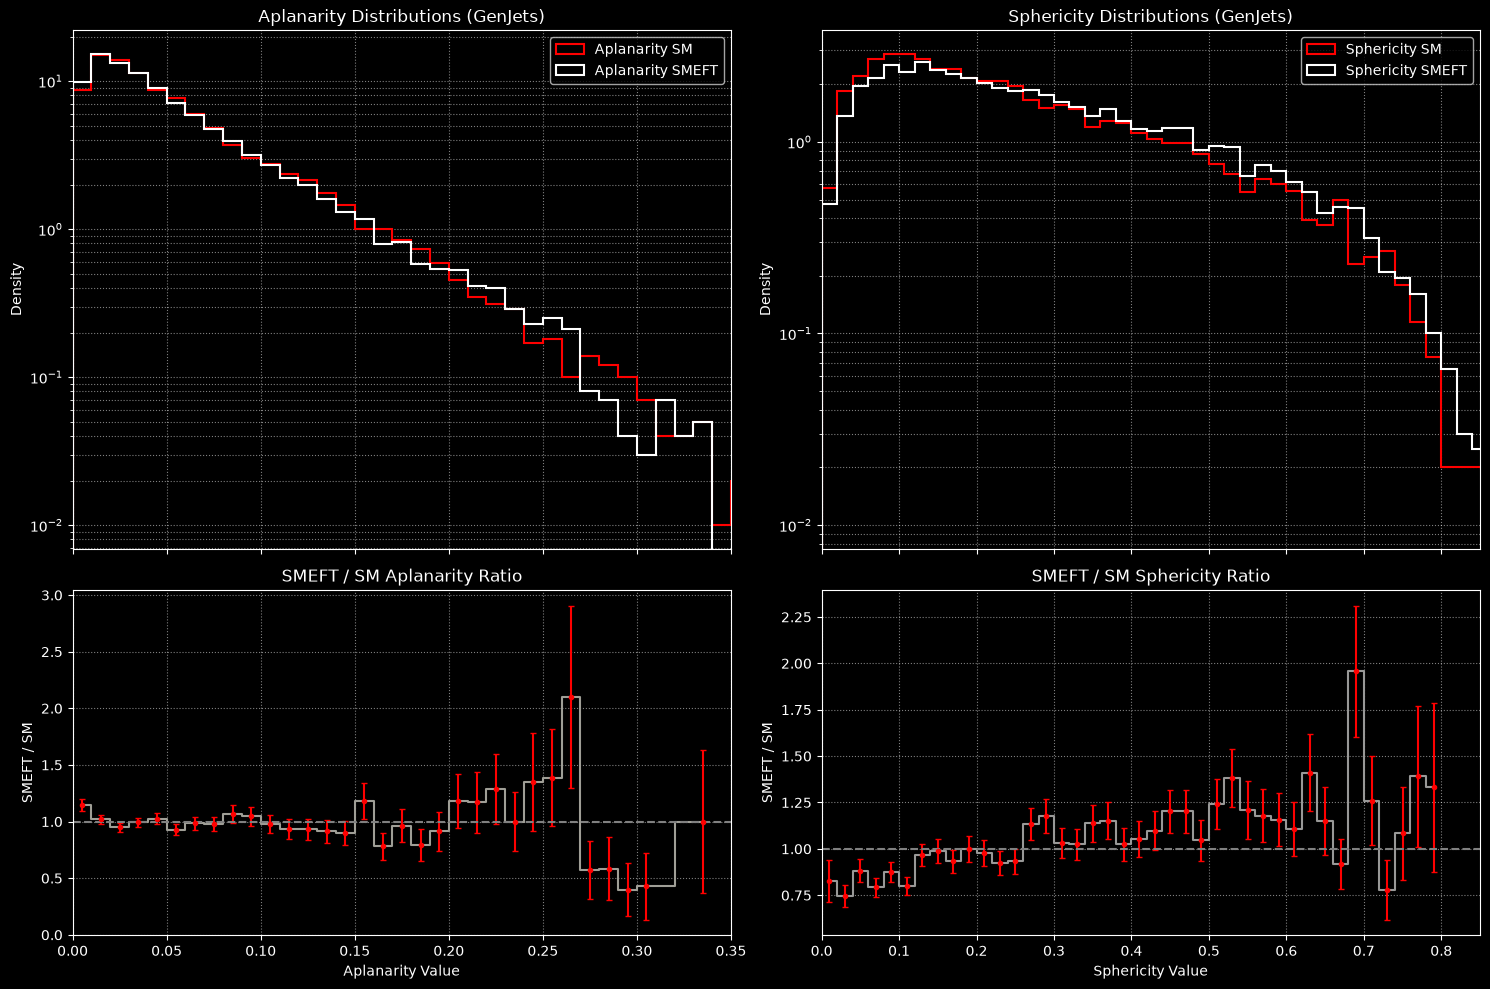

In [17]:
fig, ax = plt.subplots(2, 2, figsize=(15, 10), gridspec_kw={"height_ratios": [1.5, 1]}, sharex="col")

bins_sph = np.linspace(0, 1, 51)
bins_apl = np.linspace(0, 0.5, 51)

bin_centers_sph = 0.5 * (bins_sph[:-1] + bins_sph[1:])
bin_centers_apl = 0.5 * (bins_apl[:-1] + bins_apl[1:])

raw_counts = {}

for model, color in zip(["SM", "SMEFT"], ["#FF0000", "#FFFFFF"]):
    genpt = data_dict[model]["GenJet"]["GenJet.PT"]
    genphi = data_dict[model]["GenJet"]["GenJet.Phi"]
    geneta = data_dict[model]["GenJet"]["GenJet.Eta"]

    genpx = genpt * np.cos(genphi)
    genpy = genpt * np.sin(genphi)
    genpz = genpt * np.sinh(geneta)

    S = ak.zip({"px": genpx, "py": genpy, "pz": genpz})

    sxx = ak.sum(S.px * S.px, axis=1)
    syy = ak.sum(S.py * S.py, axis=1)
    szz = ak.sum(S.pz * S.pz, axis=1)
    sxy = ak.sum(S.px * S.py, axis=1)
    sxz = ak.sum(S.px * S.pz, axis=1)
    syz = ak.sum(S.py * S.pz, axis=1)

    p2_sum = ak.to_numpy((sxx + syy + szz))[:, None, None]

    S_mat = np.stack(
        [
            np.stack([sxx, sxy, sxz], axis=-1),
            np.stack([sxy, syy, syz], axis=-1),
            np.stack([sxz, syz, szz], axis=-1),
        ],
        axis=1,
    )

    S_tensor = np.where(p2_sum > 0, S_mat / p2_sum, 0.0)
    eig_vals = np.linalg.eigvalsh(S_tensor)

    sphericity = 1.5 * (eig_vals[:, 0] + eig_vals[:, 1])
    aplanarity = 1.5 * eig_vals[:, 0]


    ax[0, 1].hist(sphericity,bins=bins_sph,histtype="step",color=color,lw=1.5,label=f"Sphericity {model}",density=True,)
    ax[0, 0].hist(aplanarity,bins=bins_apl,histtype="step",color=color,lw=1.5,label=f"Aplanarity {model}",density=True,)

    raw_counts[model, "sph"], _ = np.histogram(sphericity, bins=bins_sph)
    raw_counts[model, "apl"], _ = np.histogram(aplanarity, bins=bins_apl)

ax[0, 1].set_ylabel("Density")
ax[0, 1].set_title("Sphericity Distributions (GenJets)")
ax[0, 1].legend()
ax[0, 1].set_yscale("log")
ax[0, 1].grid(True, which="both", linestyle=":", alpha=0.5)

ax[0, 0].set_ylabel("Density")
ax[0, 0].set_title("Aplanarity Distributions (GenJets)")
ax[0, 0].legend()
ax[0, 0].set_yscale("log")
ax[0, 0].grid(True, which="both", linestyle=":", alpha=0.5)



N_smeft_sph = raw_counts["SMEFT", "sph"]
N_sm_sph = raw_counts["SM", "sph"]

norm_smeft_sph = N_smeft_sph / np.sum(N_smeft_sph)
norm_sm_sph = N_sm_sph / np.sum(N_sm_sph)

ratio_sph = np.where(norm_sm_sph > 0, norm_smeft_sph / norm_sm_sph, np.nan)
err_sph = ratio_sph * np.sqrt(np.where(N_smeft_sph > 0, 1.0 / N_smeft_sph, 0) + np.where(N_sm_sph > 0, 1.0 / N_sm_sph, 0))
mask_sph = N_sm_sph >= 5

ax[1, 1].errorbar(bin_centers_sph[mask_sph],ratio_sph[mask_sph],yerr=err_sph[mask_sph],fmt="o",color="#FF0000",markersize=3,capsize=2,lw=1.5,)
ax[1, 1].step(bin_centers_sph[mask_sph], ratio_sph[mask_sph], where="mid", color="#989897", lw=1.5)
ax[1, 1].axhline(1.0, color="gray", linestyle="--")
ax[1, 1].set_xlabel("Sphericity Value")
ax[1, 1].set_ylabel("SMEFT / SM")
ax[1, 1].set_title("SMEFT / SM Sphericity Ratio")
ax[1, 1].grid(True, which="both", linestyle=":", alpha=0.5)
ax[1, 1].set_xlim(0, 0.85)


N_smeft_apl = raw_counts["SMEFT", "apl"]
N_sm_apl = raw_counts["SM", "apl"]

norm_smeft_apl = N_smeft_apl / np.sum(N_smeft_apl)
norm_sm_apl = N_sm_apl / np.sum(N_sm_apl)

ratio_apl = np.where(norm_sm_apl > 0, norm_smeft_apl / norm_sm_apl, np.nan)
err_apl = ratio_apl * np.sqrt(np.where(N_smeft_apl > 0, 1.0 / N_smeft_apl, 0) + np.where(N_sm_apl > 0, 1.0 / N_sm_apl, 0))
mask_apl = N_sm_apl >= 5

ax[1, 0].errorbar(bin_centers_apl[mask_apl],ratio_apl[mask_apl],yerr=err_apl[mask_apl],fmt="o",color="#FF0000",markersize=3,capsize=2,lw=1.5,)
ax[1, 0].step(bin_centers_apl[mask_apl], ratio_apl[mask_apl], where="mid", color="#9F9E96", lw=1.5)
ax[1, 0].axhline(1.0, color="gray", linestyle="--")
ax[1, 0].set_xlabel("Aplanarity Value")
ax[1, 0].set_ylabel("SMEFT / SM")
ax[1, 0].set_title("SMEFT / SM Aplanarity Ratio")
ax[1, 0].grid(True, which="both", linestyle=":", alpha=0.5)
ax[1, 0].set_xlim(0, 0.35)

plt.tight_layout()
plt.show()